# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository.  You have already used this set but this time I have removed  the first column. The set  `banknote_authentication.csv` can be found in the `data`  directory.

In [1]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import  matplotlib.pyplot as plt
from  sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from scipy.stats import multivariate_normal

In [2]:
# config

plt.rcParams['figure.figsize']=(8,8)
seed = 31287

In [3]:
# data

from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/Colab-Notebooks/Machine-Learning/Labs-11-12/data/banknote_authentication.csv')

Mounted at /content/drive


In [4]:
data.head()

,a1,a2,a3,counterfeit
0,12.3784,0.70403,-7.58360,0
1,8.1881,-3.13380,-2.52760,0
2,-10.8679,9.49260,-1.41160,1
3,-8.7903,7.97350,-0.45475,1
4,-5.5167,10.93900,-0.40820,1


### Problem A.

Perform the Quadratic Discriminant Analysis on this set. Calculate the confusion matrix, AUC score and plot the ROC curve.

In [5]:
# prepare data

X = data[['a1', 'a2', 'a3']]
y = data['counterfeit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

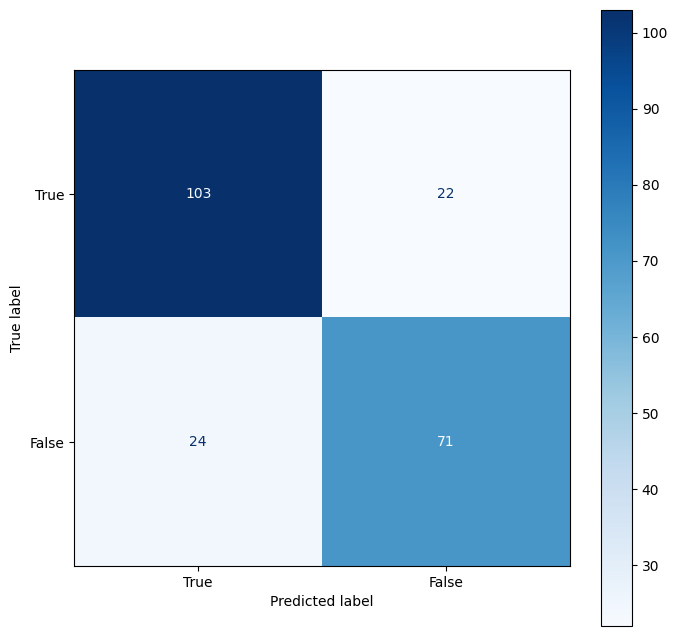

----------------------
AUC Score: 0.8514


In [6]:
# train and test QDA

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

y_pred = qda.predict(X_test)
y_prob = qda.predict_proba(X_test)[:, 1]

# evaluation
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['True', 'False'])
disp.plot(cmap='Blues')
plt.show()

auc = roc_auc_score(y_test, y_prob)
print('----------------------')
print(f'AUC Score: {auc:.4f}')

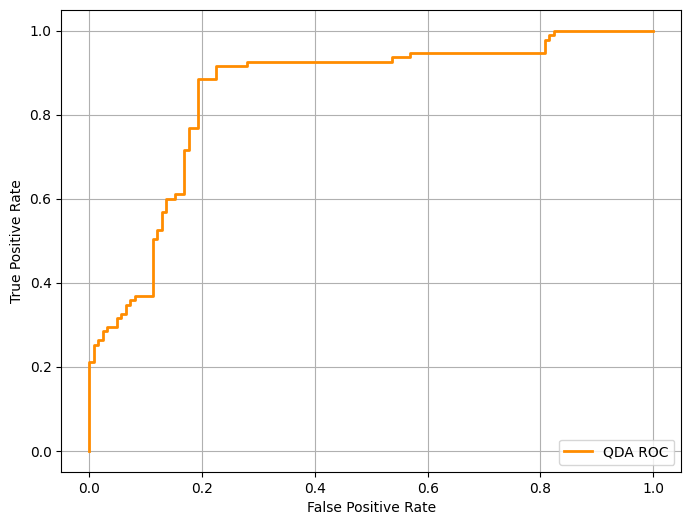

In [7]:
# plot ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='QDA ROC', color='darkorange', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Problem B.

Perform Gaussian Mixture Discriminant Analysis on this set as described in the `gaussian_mixture_model_EM_algorithm` notebook. Use two components for positives and two components for negatives. Calculate the confusion matrix, AUC score and plot the ROC curve.

In [8]:
# copied from lectures

class GaussianMixtureDiscriminantAnalysis(BaseEstimator, ClassifierMixin):
    def __init__(self, n_cmp = (2,2) , tol=1e-4 , max_iter=100 ):
        super().__init__()
        self.n_cmp = n_cmp
        self.tol = tol
        self.max_iter = max_iter

    def fit(self, X, y):
        self.X_, self.y_ = check_X_y(X, y)
        self.cls_ = [GaussianMixture(n_components=n_cmp, tol=self.tol, max_iter=self.max_iter) for n_cmp in self.n_cmp]

        for l, cmp in enumerate(self.cls_):
                cmp.fit(self.X_[self.y_==l])

        self.means_ = [cmp.means_ for cmp in self.cls_]
        self.covs_  = [cmp.covariances_ for cmp in self.cls_]
        self.pdfs_ = [[multivariate_normal(cmp.means_[i], cmp.covariances_[i]).pdf for i in range(cmp.n_components)] for cmp in self.cls_]

        return self

    def predict_proba(self, X):
        check_is_fitted(self)
        p = np.zeros((len(X),2) )
        for k,cmp in enumerate(self.cls_):
            for i in range(cmp.n_components):
                p[:,k]+= cmp.weights_[i]*self.pdfs_[k][i](X)

        proba = p[:,0]/p.sum(1)
        return  np.stack((proba, 1-proba),axis=1)

    def predict(self, X):
        X = check_array(X)
        # mirrored predictions ([:, 1]) - 0 is genuine banknote
        return (self.predict_proba(X)[:, 1] > 0.5).astype('int64')

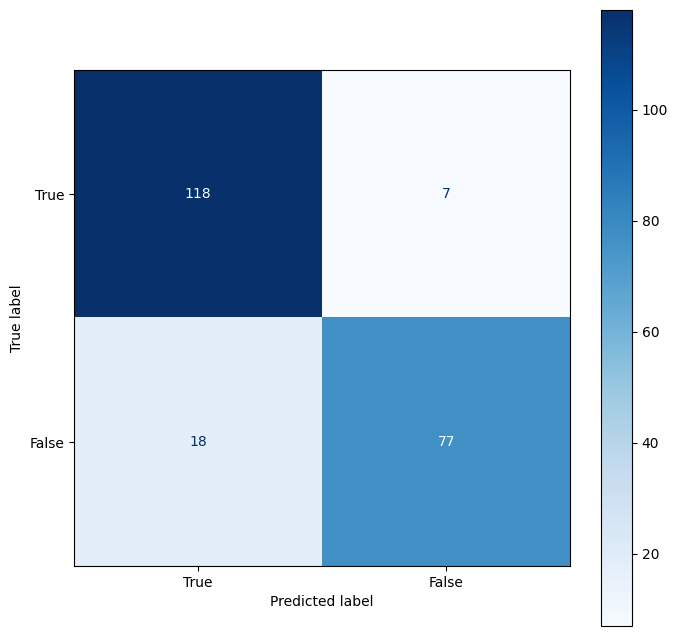

----------------------

AUC Score: 0.9468


In [9]:
# train model and predict

model_gmda = GaussianMixtureDiscriminantAnalysis(n_cmp=(2, 2)) # two components
model_gmda.fit(X_train, y_train)

y_proba_all = model_gmda.predict_proba(X_test)
y_prob = y_proba_all[:, 1]
y_pred = model_gmda.predict(X_test)

# evaluation
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['True', 'False'])
disp.plot(cmap='Blues')
plt.show()

auc = roc_auc_score(y_test, y_prob)
print('----------------------')
print(f'\nAUC Score: {auc:.4f}')

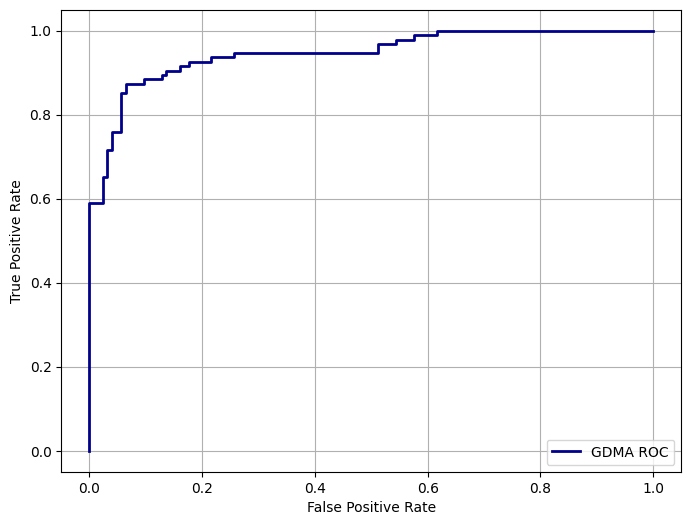

In [10]:
# plot ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'GDMA ROC', color='darkblue', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Problem C.

Use k-fold cross validation to find the optimal number of gaussian components for each class. As before calculate the confusion matrix, AUC score and plot the ROC curve for the best classifier. Assume that maximal number of components in each class is 12.  

In [19]:
# k-fold choosing

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

max_components = 12
best_auc = -1
best_n_cmp = None

# iterate 1 - 12 and train a model
for n in range(1, max_components + 1):
    fold_aucs = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.values[train_idx], X_train.values[val_idx]
        y_tr, y_val = y_train.values[train_idx], y_train.values[val_idx]

        model = GaussianMixtureDiscriminantAnalysis(n_cmp=(n, n))

        try:
            model.fit(X_tr, y_tr)
            y_prob_val = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_prob_val)
            fold_aucs.append(auc)
        except Exception as e:
            continue

    # choose best
    if fold_aucs:
        mean_auc = np.mean(fold_aucs)
        print(f"With: ({n}, {n}) | Mean AUC = {mean_auc:.4f}")

        if mean_auc > best_auc:
            best_auc = mean_auc
            best_n_cmp = (n, n)

print(f"Best number of components: {best_n_cmp} with AUC = {best_auc:.4f}")

With: (1, 1) | Mean AUC = 0.8963
With: (2, 2) | Mean AUC = 0.9626
With: (3, 3) | Mean AUC = 0.9727
With: (4, 4) | Mean AUC = 0.9803
With: (5, 5) | Mean AUC = 0.9863
With: (6, 6) | Mean AUC = 0.9895
With: (7, 7) | Mean AUC = 0.9874
With: (8, 8) | Mean AUC = 0.9897
With: (9, 9) | Mean AUC = 0.9897
With: (10, 10) | Mean AUC = 0.9908
With: (11, 11) | Mean AUC = 0.9889
With: (12, 12) | Mean AUC = 0.9904
Best number of components: (10, 10) with AUC = 0.9908


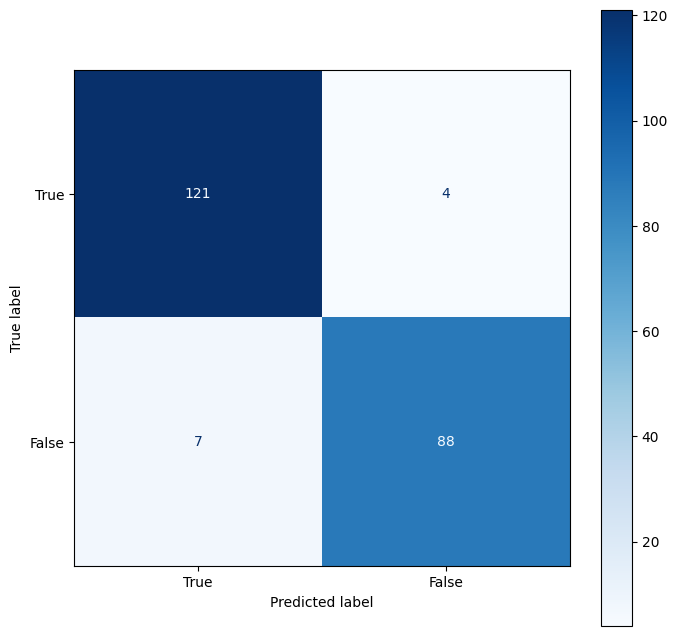

----------------------

AUC Score: 0.9472


In [20]:
# train and evaluate best GMDA model

best_model = GaussianMixtureDiscriminantAnalysis(n_cmp=best_n_cmp)
best_model.fit(X_train, y_train)

y_prob_test_best = best_model.predict_proba(X_test)[:, 1]
y_pred_test_best = best_model.predict(X_test)

cm_best = confusion_matrix(y_test, y_pred_test_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['True', 'False'])
disp.plot(cmap='Blues')
plt.show()

auc_best = roc_auc_score(y_test, y_pred_test_best)
print('----------------------')
print(f'\nAUC Score: {auc_best:.4f}')

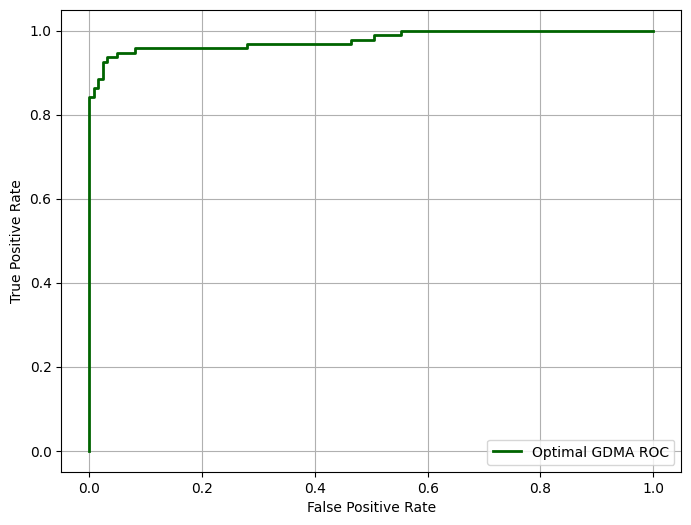

In [21]:
# plor ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Optimal GDMA ROC', color='darkgreen', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Problem D.  

Assume that 1% of all the customers in your store try to pay with a counterfeit 100PLN bill. If you accept the counterfeit bill you loose 100PLN. If you reject a valid bill,  you may loose the purchase, you estimate this loss as 15PLN on average. For each of the three classifiers find the threshold that minimises your losses and calculates the minimum loss for each classifier. Show the optimal classifiers points on the ROC curves.

In [22]:
# finance values

p_pos = 0.01  # P(Counterfeit)
p_neg = 0.99  # P(Valid)
cost_fn = 100  # accept counterfeit bill loss
cost_fp = 15   # reject valid bill loss

In [23]:
# optimalize mean loss for any model (y_true, y_proba)

def calculate_optimal_threshold(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)

    losses = p_neg * fpr * cost_fp + p_pos * (1 - tpr) * cost_fn

    best_idx = np.argmin(losses)
    best_thresh = thresholds[best_idx]
    min_loss = losses[best_idx]

    return best_thresh, min_loss, fpr[best_idx], tpr[best_idx]

In [24]:
# models from problems A, B & C

model_qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)
prob_qda = model_qda.predict_proba(X_test)[:, 1]

model_gmda_b = GaussianMixtureDiscriminantAnalysis(n_cmp=(2, 2)).fit(X_train, y_train)
prob_gmda_b = model_gmda_b.predict_proba(X_test)[:, 1]

model_gmda_c = GaussianMixtureDiscriminantAnalysis(n_cmp=best_n_cmp).fit(X_train, y_train)
prob_gmda_c = model_gmda_c.predict_proba(X_test)[:, 1]

models_dict = {
    'QDA': prob_qda,
    'GMDA (2,2)': prob_gmda_b,
    f'GMDA {best_n_cmp}': prob_gmda_c
}

Optimalization results:
----------------------
Model: QDA
    Threshold: 0.9665
    Mean loss per banknote: 0.79 PLN
    Point on ROC curve: (FPR=0.000, TPR=0.211)
----------------------
Model: GMDA (2,2)
    Threshold: 0.9143
    Mean loss per banknote: 0.41 PLN
    Point on ROC curve: (FPR=0.000, TPR=0.589)
----------------------
Model: GMDA (10, 10)
    Threshold: 0.9198
    Mean loss per banknote: 0.19 PLN
    Point on ROC curve: (FPR=0.000, TPR=0.811)
----------------------


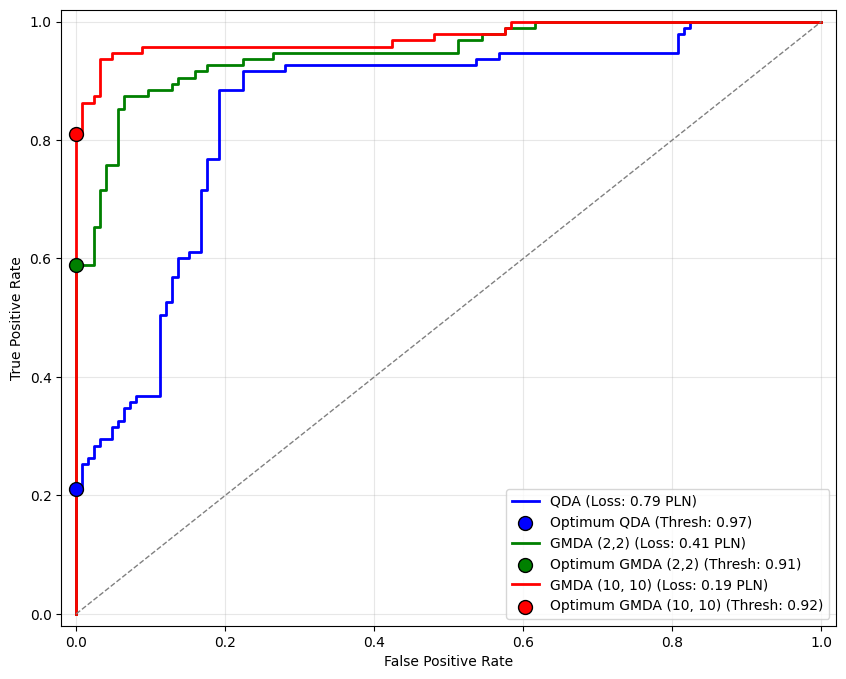

In [25]:
# optimalization and plotting

plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red']

print("Optimalization results:")
print('----------------------')

for (model_name, proba), color in zip(models_dict.items(), colors):
    thresh, min_loss, f_rate, t_rate = calculate_optimal_threshold(y_test, proba)

    print(f"Model: {model_name}")
    print(f"    Threshold: {thresh:.4f}")
    print(f"    Mean loss per banknote: {min_loss:.2f} PLN")
    print(f"    Point on ROC curve: (FPR={f_rate:.3f}, TPR={t_rate:.3f})")
    print('----------------------')

    # plot curve with point
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{model_name} (Loss: {min_loss:.2f} PLN)', color=color, lw=2)
    plt.scatter(f_rate, t_rate, color=color, s=100, edgecolors='black', zorder=5,
                label=f'Optimum {model_name} (Thresh: {thresh:.2f})')

plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()